Cylinder trial table:
   trial channel     M_obs  signal_rate         f         M_sig  valid
0      1     Ch2  8.546660     9.745342  0.009635    515.472600   True
1      1     Ch3  8.352764     0.981366  0.000970   4886.724839   True
2      1     Ch4  7.555755     4.161491  0.004114    961.445295   True
3      3     Ch2  5.227565     0.174402  0.000172   9356.791128   True
4      3     Ch3  3.558230     0.485232  0.000480   -114.256863  False
5      3     Ch4  7.572332     0.233474  0.000231  17148.005460   True
6      4     Ch2  0.158096     0.087622  0.000087 -39897.059134  False
7      4     Ch4 -0.103040     0.051460  0.000051 -73068.604859  False
8      5     Ch2  3.042832     0.391549  0.000387  -1473.803630  False
9      5     Ch4  2.897411     0.108451  0.000107  -6686.634163  False

Summary mode: median
Summary M_sig = 4886.725
ln(summary M_sig) = 8.494


/opt/homebrew/Caskroom/miniforge/base/envs/respirometry/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/pg/rkmvtptx175d4dsj5fd6w4d40000gp/T/ipykernel_77496/162124449.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


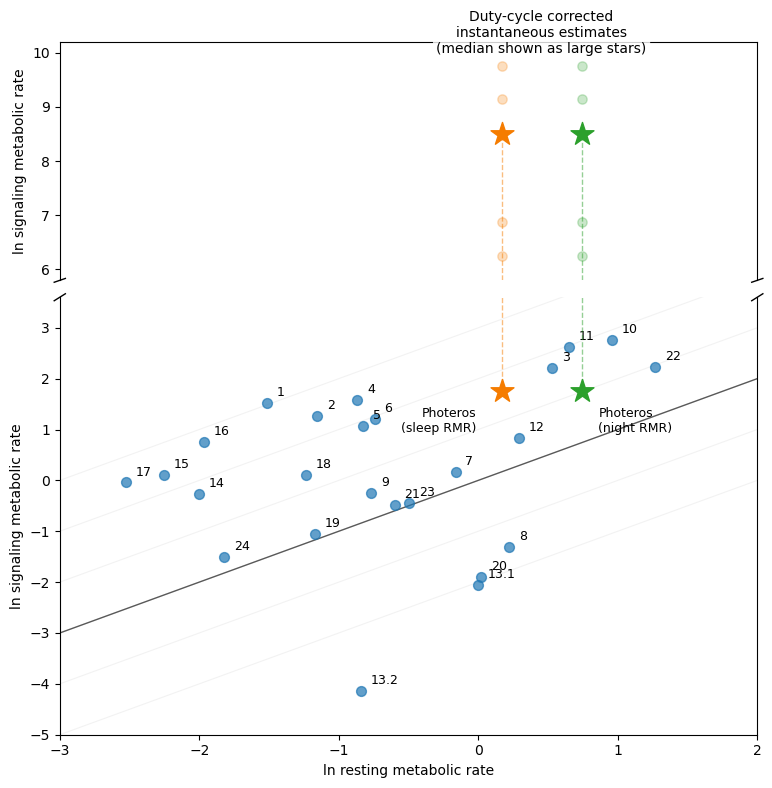

In [4]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# =========================================================
# 1) INPUT DATA
# =========================================================

# Literature compilation
lit = pd.DataFrame([
    (1,   "spider", 4.580, 0.220),
    (2,   "insect", 3.576, 0.315),
    (3,   "insect", 9.060, 1.700),
    (4,   "insect", 4.883, 0.420),
    (5,   "insect", 2.931, 0.437),
    (6,   "insect", 3.342, 0.476),
    (7,   "insect", 1.170, 0.850),
    (8,   "insect", 0.270, 1.250),
    (9,   "insect", 0.774, 0.464),
    (10,  "insect", 15.790, 2.610),
    (11,  "insect", 13.880, 1.920),
    (12,  "insect", 2.320, 1.340),
    ("13.1", "fish", 0.127, 0.995),
    ("13.2", "fish", 0.016, 0.432),
    (14,  "frog",   0.770, 0.135),
    (15,  "frog",   1.120, 0.105),
    (16,  "frog",   2.110, 0.140),
    (17,  "frog",   0.960, 0.080),
    (18,  "frog",   1.110, 0.290),
    (19,  "frog",   0.350, 0.310),
    (20,  "bird",   0.150, 1.020),
    (21,  "bird",   0.620, 0.550),
    (22,  "bird",   9.300, 3.560),
    (23,  "bird",   0.640, 0.610),
    (24,  "bird",   0.222, 0.162),
], columns=["sp_no", "group", "signal", "rest"])

# Photeros summary values
small_day = 1.181223
small_night = 2.097811
cylinder_night_mean = 5.844194
medium_night = 3.614779  # activity / swimming baseline

# Cylinder-level data
cyl = pd.DataFrame({
    "trial": [1, 1, 1, 3, 3, 3, 4, 4, 5, 5],
    "channel": ["Ch2", "Ch3", "Ch4", "Ch2", "Ch3", "Ch4", "Ch2", "Ch4", "Ch2", "Ch4"],
    "M_obs": [8.546660, 8.352764, 7.555755, 5.227565, 3.558230, 7.572332, 0.158096, -0.103040, 3.042832, 2.897411],
    "signal_rate": [9.745342, 0.981366, 4.161491, 0.174402, 0.485232, 0.233474, 0.087622, 0.051460, 0.391549, 0.108451],
})

# Behavioral conversion values
pulses_per_train = 4.5
train_duration_s = 16.017

# =========================================================
# 2) DERIVED VALUES
# =========================================================

lit["ln_rest"] = np.log(lit["rest"])
lit["ln_signal"] = np.log(lit["signal"])

# Trial-specific duty cycle
cyl["trains_per_hr"] = cyl["signal_rate"] / pulses_per_train
cyl["signal_time_s_per_hr"] = cyl["trains_per_hr"] * train_duration_s
cyl["f"] = cyl["signal_time_s_per_hr"] / 3600.0

# Duty-cycle corrected active signaling rate assuming:
# M_obs = f * M_sig + (1 - f) * M_swim
# => M_sig = [M_obs - (1-f) * M_swim] / f
cyl["M_sig"] = (cyl["M_obs"] - (1.0 - cyl["f"]) * medium_night) / cyl["f"]

# Valid corrected values
cyl["valid"] = np.isfinite(cyl["M_sig"]) & (cyl["M_sig"] > 0)
cyl["ln_M_sig"] = np.where(cyl["valid"], np.log(cyl["M_sig"]), np.nan)

valid_ln = cyl.loc[cyl["valid"], "ln_M_sig"].dropna().values
valid_Msig = cyl.loc[cyl["valid"], "M_sig"].dropna().values

print("Cylinder trial table:")
print(cyl[["trial", "channel", "M_obs", "signal_rate", "f", "M_sig", "valid"]])
print()

# Choose summary statistic for upper stars
summary_mode = "median"  # options: "median", "geomean", "mean"

if summary_mode == "median":
    M_sig_summary = float(np.median(valid_Msig))
elif summary_mode == "geomean":
    M_sig_summary = float(np.exp(np.mean(np.log(valid_Msig))))
elif summary_mode == "mean":
    M_sig_summary = float(np.mean(valid_Msig))
else:
    raise ValueError("summary_mode must be 'median', 'geomean', or 'mean'")

ln_M_sig_summary = math.log(M_sig_summary)

print(f"Summary mode: {summary_mode}")
print(f"Summary M_sig = {M_sig_summary:.3f}")
print(f"ln(summary M_sig) = {ln_M_sig_summary:.3f}")

# Observed Photeros coordinates
x_day = math.log(small_day)
x_night = math.log(small_night)
y_obs = math.log(cylinder_night_mean)

# =========================================================
# 3) OPTIONAL: LOCAL PHYLOPIC ICONS
# =========================================================
# Put one icon PNG per group in ./icons/
# Example filenames:
#   icons/spider.png
#   icons/insect.png
#   icons/fish.png
#   icons/frog.png
#   icons/bird.png

ICON_DIR = Path("icons")
icon_paths = {
    "spider": ICON_DIR / "spider.png",
    "insect": ICON_DIR / "insect.png",
    "fish":   ICON_DIR / "fish.png",
    "frog":   ICON_DIR / "frog.png",
    "bird":   ICON_DIR / "bird.png",
}

def add_icon(ax, x, y, path, zoom=0.11):
    path = Path(path)
    if not path.exists():
        return False
    img = plt.imread(path)
    artist = AnnotationBbox(
        OffsetImage(img, zoom=zoom),
        (x, y),
        frameon=False,
        box_alignment=(0.5, 0.5),
        zorder=3,
    )
    ax.add_artist(artist)
    return True

# =========================================================
# 4) PLOTTING HELPERS
# =========================================================

def draw_reference_lines(ax, xmin=-3, xmax=2):
    xline = np.linspace(xmin, xmax, 300)
    for intercept in range(-2, 4):
        ax.plot(xline, xline + intercept, lw=0.8, alpha=0.14, color="0.65", zorder=0)
    ax.plot(xline, xline, lw=1.0, color="0.35", zorder=1)

def plot_literature(ax):
    for _, row in lit.iterrows():
        used_icon = add_icon(ax, row["ln_rest"], row["ln_signal"], icon_paths[row["group"]], zoom=0.11)
        if not used_icon:
            ax.scatter(
                row["ln_rest"], row["ln_signal"],
                s=50, alpha=0.7, color="tab:blue", zorder=2
            )
        ax.annotate(
            str(row["sp_no"]),
            (row["ln_rest"], row["ln_signal"]),
            xytext=(7, 5),
            textcoords="offset points",
            fontsize=9,
            zorder=4,
        )

def add_break_marks(ax_top, ax_bottom, d=0.008):
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, lw=1.0)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# =========================================================
# 5) BUILD FIGURE WITH BROKEN Y-AXIS
# =========================================================

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(9, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 2.2], "hspace": 0.05}
)

xmin, xmax = -3, 2
bottom_ylim = (-5, 3.6)
top_ylim = (5.8, 10.2)

for ax in (ax_top, ax_bottom):
    ax.set_xlim(xmin, xmax)
    draw_reference_lines(ax, xmin=xmin, xmax=xmax)

ax_bottom.set_ylim(*bottom_ylim)
ax_top.set_ylim(*top_ylim)

# Literature and observed Photeros only on lower panel
plot_literature(ax_bottom)

# Lower-panel observed Photeros stars
ax_bottom.scatter([x_day], [y_obs], marker="*", s=300, color="#f57c00", zorder=6)
ax_bottom.scatter([x_night], [y_obs], marker="*", s=300, color="#2ca02c", zorder=6)

ax_bottom.annotate(
    "Photeros\n(sleep RMR)",
    (x_day, y_obs),
    xytext=(-18, -30),
    textcoords="offset points",
    fontsize=9,
    ha="right",
    zorder=7,
)

ax_bottom.annotate(
    "Photeros\n(night RMR)",
    (x_night, y_obs),
    xytext=(12, -30),
    textcoords="offset points",
    fontsize=9,
    ha="left",
    zorder=7,
)

# Upper-panel corrected cloud
for yv in valid_ln:
    ax_top.scatter([x_day], [yv], s=45, color="#f57c00", alpha=0.25, zorder=5)
    ax_top.scatter([x_night], [yv], s=45, color="#2ca02c", alpha=0.25, zorder=5)

# Summary stars in upper panel
ax_top.scatter([x_day], [ln_M_sig_summary], marker="*", s=300, color="#f57c00", zorder=7)
ax_top.scatter([x_night], [ln_M_sig_summary], marker="*", s=300, color="#2ca02c", zorder=7)

# Upper-panel label
label_y = min(max(valid_ln.max(), ln_M_sig_summary) + 0.18, top_ylim[1] - 0.15)
ax_top.text(
    (x_day + x_night) / 2,
    label_y,
    f"Duty-cycle corrected\ninstantaneous estimates\n({summary_mode} shown as large stars)",
    ha="center",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8),
    zorder=8,
)

# Optional dashed connectors between lower and upper stars
ax_bottom.plot([x_day, x_day], [y_obs, bottom_ylim[1]], ls="--", lw=1.0, color="#f57c00", alpha=0.5, zorder=4)
ax_bottom.plot([x_night, x_night], [y_obs, bottom_ylim[1]], ls="--", lw=1.0, color="#2ca02c", alpha=0.5, zorder=4)
ax_top.plot([x_day, x_day], [top_ylim[0], ln_M_sig_summary], ls="--", lw=1.0, color="#f57c00", alpha=0.5, zorder=4)
ax_top.plot([x_night, x_night], [top_ylim[0], ln_M_sig_summary], ls="--", lw=1.0, color="#2ca02c", alpha=0.5, zorder=4)

# Formatting
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False)
ax_bottom.tick_params(top=False)

add_break_marks(ax_top, ax_bottom)

ax_bottom.set_xlabel("ln resting metabolic rate")
ax_bottom.set_ylabel("ln signaling metabolic rate")
ax_top.set_ylabel("ln signaling metabolic rate")

# Optional remove upper x tick labels
ax_top.xaxis.set_visible(False)

# Optional title
# ax_top.set_title("Comparative signaling costs with Photeros")

plt.tight_layout()
plt.show()